## Imports and setup

In [1]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from skimage.morphology import remove_small_objects
from scipy.ndimage import distance_transform_edt
import warnings
import gc

warnings.filterwarnings('ignore')

## Helper functions and shapefile loading

In [2]:
# Function to load a raster and crop it using a vector shapefile
def load_and_crop_raster(raster_path, shapes):
    with rasterio.open(raster_path) as src:
        # Crop the image using the geometry
        out_image, _ = mask(src, shapes.geometry, crop=True)
        return out_image[0]

# Load the vector boundary of the vineyard rows
shapefile_path = "data/vineyard_shape.shp"
vineyard_vector = gpd.read_file(shapefile_path)

print(f"CRS: {vineyard_vector.crs}")

CRS: EPSG:4326


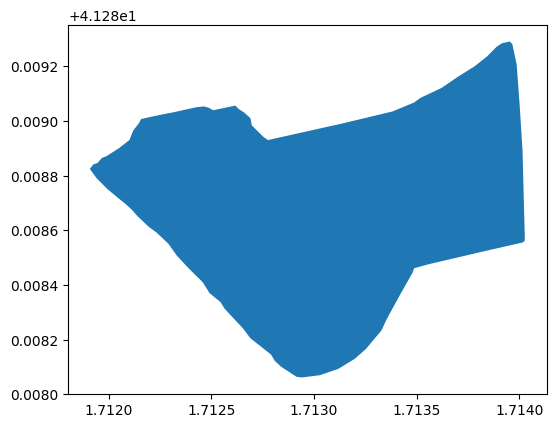

In [3]:
vineyard_vector.plot()
plt.show()

## Loading, cropping and aligning multispectral data

In [4]:
path_nir  = "data/CROPPED_ORTHOMOSAIC_240618_NIR.tif"
path_re   = "data/CROPPED_ORTHOMOSAIC_240618_RE.tif"
path_r    = "data/CROPPED_ORTHOMOSAIC_240618_R.tif"
path_g    = "data/CROPPED_ORTHOMOSAIC_240618_G.tif"
path_ndvi = "data/CROPPED_ORTHOMOSAIC_240618_NDVI.tif"

nir_raw  = load_and_crop_raster(path_nir, vineyard_vector)
re_raw   = load_and_crop_raster(path_re, vineyard_vector)
r_raw    = load_and_crop_raster(path_r, vineyard_vector)
g_raw    = load_and_crop_raster(path_g, vineyard_vector)
ndvi_raw = load_and_crop_raster(path_ndvi, vineyard_vector)

# Sometimes we had 1-2 pixels difference.
min_h = min(nir_raw.shape[0], re_raw.shape[0], r_raw.shape[0], g_raw.shape[0], ndvi_raw.shape[0])
min_w = min(nir_raw.shape[1], re_raw.shape[1], r_raw.shape[1], g_raw.shape[1], ndvi_raw.shape[1])

nir  = nir_raw[:min_h, :min_w].astype(float)
re   = re_raw[:min_h, :min_w].astype(float)
r    = r_raw[:min_h, :min_w].astype(float)
g    = g_raw[:min_h, :min_w].astype(float)
ndvi = ndvi_raw[:min_h, :min_w].astype(float)

# # Free up RAM (Garbage Collection)
# del nir_raw, re_raw, r_raw, g_raw, ndvi_raw
# gc.collect()

## NDRE Calculation and masking of vegetation

In [6]:
ndre = (nir - re) / (nir + re)
ndre = np.nan_to_num(ndre, nan=0.0, posinf=0.0, neginf=0.0)

# I choose threshold of 0.1 or 0.2
# Vegetation indices like NDRE range from -1 to 1.
# Values <= 0.1 typically represent bare soil, shadows, or dead material.
#  to extract ONLY the vine canopy for clustering
valid_mask_2d = ndre > 0.1

print(f"Total valid pixels: {np.sum(valid_mask_2d)}")

Total valid pixels: 26244582


## Impact of normalization like in paper for clustering

In [7]:
multi_features = np.column_stack((
    ndre[valid_mask_2d],
    ndvi[valid_mask_2d],
    nir[valid_mask_2d],
    r[valid_mask_2d],
    g[valid_mask_2d]
))

# 1. NO NORMALIZATION
unscaled_data = multi_features

# 2. WITH NORMALIZATION (MinMaxScaler scales all features to 0.0 - 1.0)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(multi_features)

print(f"UNSCALED Data -> NDRE max: {unscaled_data[:,0].max():.2f} | NIR max: {unscaled_data[:,2].max():.2f}")
print(f"SCALED Data   -> NDRE max: {scaled_data[:,0].max():.2f} | NIR max: {scaled_data[:,2].max():.2f}")
print("Cell 5 Executed.")

UNSCALED Data -> NDRE max: 1.00 | NIR max: 39333.00
SCALED Data   -> NDRE max: 1.00 | NIR max: 1.00
Cell 5 Executed.


## Finding the optimal number of clusters

Alternatives for silhouette score: Elbow method, Davies-Bouldin

K = 2 | Silhouette: 0.4522 | Davies-Bouldin: 0.8813 | Inertia: 2713
K = 3 | Silhouette: 0.3017 | Davies-Bouldin: 1.4785 | Inertia: 2345
K = 4 | Silhouette: 0.2491 | Davies-Bouldin: 1.5052 | Inertia: 2033
K = 5 | Silhouette: 0.2558 | Davies-Bouldin: 1.3393 | Inertia: 1805
K = 6 | Silhouette: 0.2535 | Davies-Bouldin: 1.3247 | Inertia: 1642


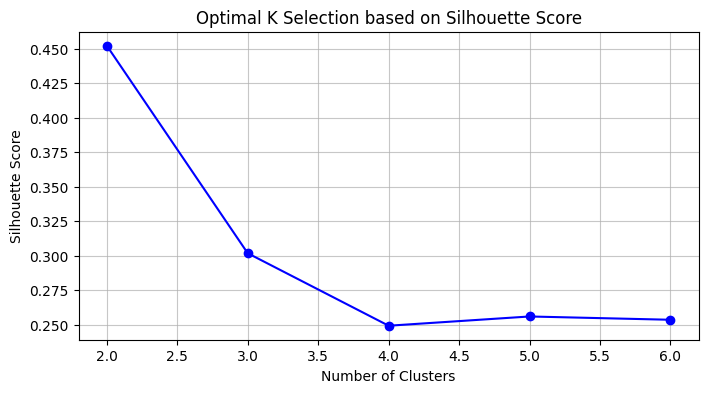

In [8]:
np.random.seed(42)
sample_size = min(30000, scaled_data.shape[0])
sample_indices = np.random.choice(scaled_data.shape[0], size=sample_size, replace=False)
features_sample = scaled_data[sample_indices]

k_values = range(2, 7)
inertias = []
silhouette_scores = []
db_scores = []

for k in k_values:
    # Use fast K-Means to evaluate metrics
    km_test = KMeans(n_clusters=k, random_state=123, n_init=5)
    labels = km_test.fit_predict(features_sample)
    
    # 1. Inertia (for Elbow Method)
    inertias.append(km_test.inertia_)
    
    # 2. Silhouette Score (Higher is better)
    sil_score = silhouette_score(features_sample, labels)
    silhouette_scores.append(sil_score)
    
    # 3. Davies-Bouldin Index (Lower is better)
    db_score = davies_bouldin_score(features_sample, labels)
    db_scores.append(db_score)
    
    print(f"K = {k} | Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f} | Inertia: {km_test.inertia_:.0f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', color='blue')
plt.title('Optimal K Selection based on Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.7)
plt.show()

In [9]:
# Silhouette mathematically favors K=2.
# K=3 or K=4 may be more useful
optimal_k = 3 

## Advanced clustering with GMM and sorting the clusters

In [10]:
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=123)

# Training on sample, predict on the full dataset
gmm.fit(features_sample)
raw_labels = gmm.predict(scaled_data)

In [11]:
# We want Label 1 = Worst Vegetation (Red), Highest Label = Best Vegetation (Green)
cluster_means = []
for i in range(optimal_k):
    # Calculate average NDRE for each cluster
    mean_ndre = np.mean(unscaled_data[raw_labels == i, 0]) 
    cluster_means.append((i, mean_ndre))

# Sort clusters by mean NDRE (ascending order)
cluster_means.sort(key=lambda x: x[1])

# Create a mapping dictionary: old_label -> new_sorted_label (starting from 1)
label_mapping = {old_label: new_label + 1 for new_label, (old_label, _) in enumerate(cluster_means)}

# Apply the mapping to get sorted labels
sorted_labels = np.array([label_mapping[label] for label in raw_labels])

print("Cluster centers sorted by NDRE values:")
for old, mean_val in cluster_means:
    print(f"Mapped to Zone {label_mapping[old]}: Avg NDRE = {mean_val:.3f}")

# Reconstruct the 2D map
clusters_2d = np.zeros_like(ndre, dtype=int)
clusters_2d[valid_mask_2d] = sorted_labels

Cluster centers sorted by NDRE values:
Mapped to Zone 1: Avg NDRE = 0.235
Mapped to Zone 2: Avg NDRE = 0.267
Mapped to Zone 3: Avg NDRE = 0.279


## Spatial smoothing (CaSP Algorithm) as in paper

Better than DBSCAN because of computational cost

In [12]:
# MIN_ISLAND_SIZE: Minimum area (in pixels) for a management zone to be kept.
# If a robot's variable-rate sprayer has a 5x5m resolution, islands smaller 
# than this mechanical constraint must be merged with surrounding zones.
min_island_size = 5000

smoothed_clusters = np.zeros_like(clusters_2d)
valid_large_areas_mask = np.zeros_like(clusters_2d, dtype=bool)

# 1. Remove small isolated patches (Islands) for each zone
for cluster_id in range(1, optimal_k + 1):
    bin_mask = (clusters_2d == cluster_id)
    clean_mask = remove_small_objects(bin_mask, min_size=min_island_size)
    smoothed_clusters[clean_mask] = cluster_id
    valid_large_areas_mask = valid_large_areas_mask | clean_mask

# 2. Re-assign the empty holes to the nearest valid zone
inv_mask = ~valid_large_areas_mask 
distances, indices = distance_transform_edt(inv_mask, return_indices=True)

final_casp_clusters = smoothed_clusters[indices[0], indices[1]]

# 3. Restore the global background (bare soil, tracks, roads) to 0
final_casp_clusters[~valid_mask_2d] = 0

## Final Solution

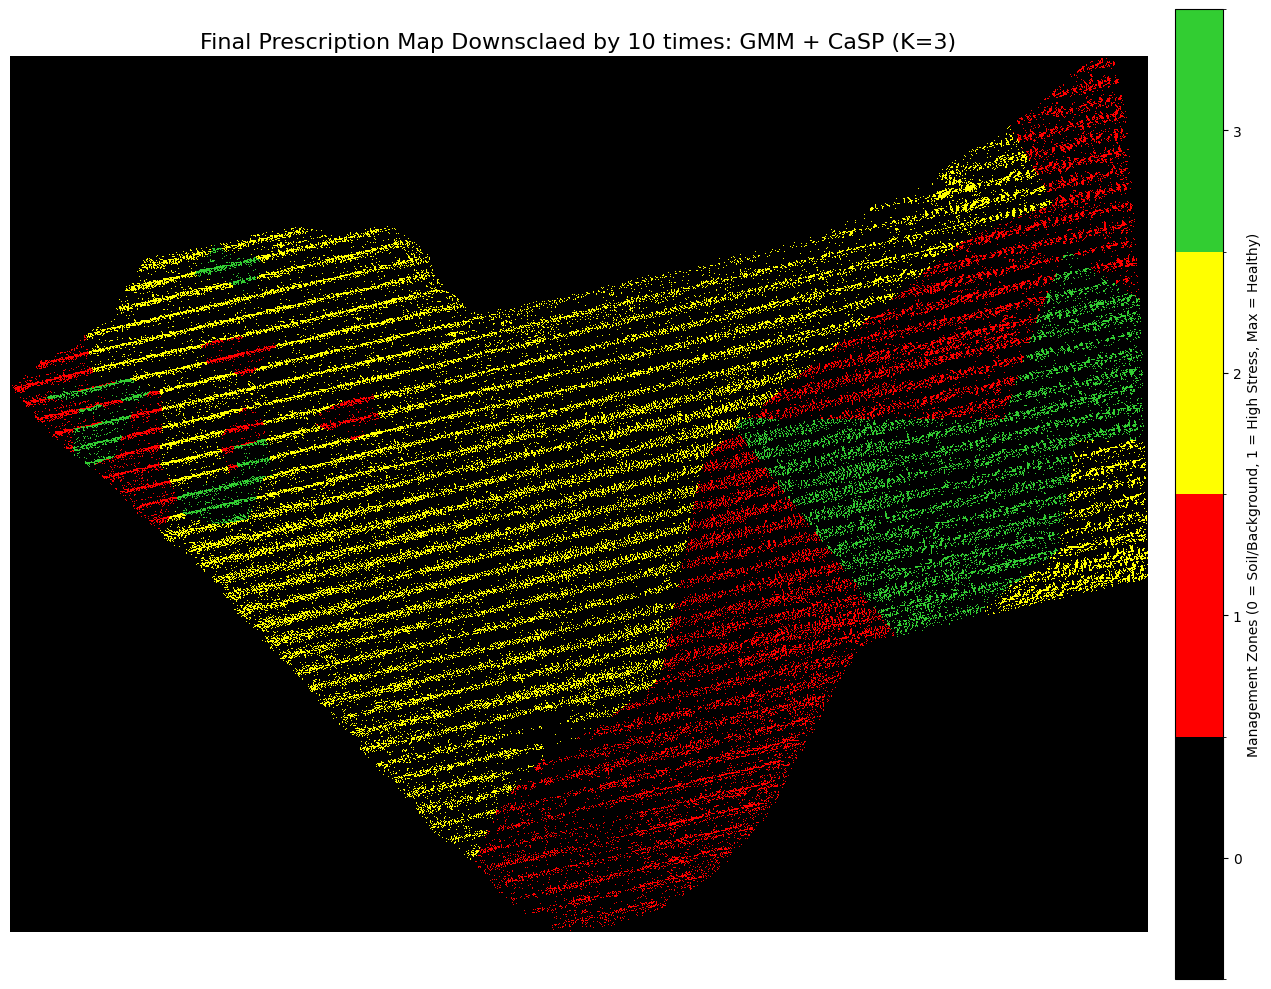

In [13]:
final_casp_clusters_uint8 = final_casp_clusters.astype(np.uint8)

# Define colormap
color_list = ['black', 'red', 'yellow', 'limegreen', 'dodgerblue', 'darkviolet']
cmap_zones = ListedColormap(color_list[:optimal_k + 1])
bounds = np.arange(optimal_k + 2) - 0.5
norm = BoundaryNorm(bounds, cmap_zones.N)

# --- VISUALIZATION PREVIEW (DOWNSAMPLED FOR SCREEN) ---
# Matplotlib cannot efficiently display a 270-million-pixel image.
# We create a lightweigh downscaling by factor of 10
step = 10 
preview_map = final_casp_clusters_uint8[::step, ::step]

plt.figure(figsize=(14, 10))
plt.imshow(preview_map, cmap=cmap_zones, norm=norm, interpolation='nearest')

cbar = plt.colorbar(ticks=range(optimal_k + 1), pad=0.02)
cbar.set_label('Management Zones (0 = Soil/Background, 1 = High Stress, Max = Healthy)')

plt.title(f'Final Prescription Map Downsclaed by {step} times: GMM + CaSP (K={optimal_k})', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

## Check stats in clusters

CALCULATION OF VRI (VARIANCE REDUCTION INDEX)

In [14]:
print("MULTI-DIMENSIONAL VARIANCE ANALYSIS (5 FEATURES)")

# scaled_data contains all 5 normalized channels for valid plant pixels
# We calculate total variance across all 5 dimensions (sum of variances)
total_var_multi = np.sum(np.var(scaled_data, axis=0))
total_pixels = scaled_data.shape[0]

print(f"Total Field Variance (5D): {total_var_multi:.4f}\n")

# 1. VRI FOR PURE GMM MODEL (Before Smoothing)
# Extract 1D labels from the 2D map for valid pixels
labels_raw_1d = clusters_2d[valid_mask_2d]
weighted_var_sum_raw = 0

for zone_id in range(1, optimal_k + 1):
    # Select only the pixels (with all 5 layers) that belong to the current zone
    zone_features_raw = scaled_data[labels_raw_1d == zone_id]
    zone_pixels_count = zone_features_raw.shape[0]
    
    if zone_pixels_count > 0:
        # Sum of variances for all 5 layers within this zone
        zone_var_multi = np.sum(np.var(zone_features_raw, axis=0))
        weight = zone_pixels_count / total_pixels
        weighted_var_sum_raw += (weight * zone_var_multi)

vri_multi_raw = (1 - (weighted_var_sum_raw / total_var_multi)) * 100


# 2. VRI FOR TRACTOR-READY CaSP MAP (After Smoothing)
labels_casp_1d = final_casp_clusters[valid_mask_2d]
weighted_var_sum_casp = 0

for zone_id in range(1, optimal_k + 1):
    zone_features_casp = scaled_data[labels_casp_1d == zone_id]
    zone_pixels_count = zone_features_casp.shape[0]
    
    if zone_pixels_count > 0:
        zone_var_multi = np.sum(np.var(zone_features_casp, axis=0))
        weight = zone_pixels_count / total_pixels
        weighted_var_sum_casp += (weight * zone_var_multi)

vri_multi_casp = (1 - (weighted_var_sum_casp / total_var_multi)) * 100


print(f"Multi-VRI Result (Pure GMM Model): {vri_multi_raw:.2f}%")
print(f"Multi-VRI Result (After CaSP Algorithm): {vri_multi_casp:.2f}%\n")

MULTI-DIMENSIONAL VARIANCE ANALYSIS (5 FEATURES)
Total Field Variance (5D): 0.1904

Multi-VRI Result (Pure GMM Model): 55.88%
Multi-VRI Result (After CaSP Algorithm): 1.32%




1. A high Multi-VRI for the pure GMM indicates that the model successfully identified multi-dimensional patterns.
2. The drop in VRI after applying CaSP represents the mathematical cost of unifying zones (the trade-off between statistical accuracy and robotic navigability).")

In [15]:
# Stats just for NDVI
for zone in [1, 2, 3]:
    zone_mask = (final_casp_clusters == zone)
    print(f" Cluster {zone}:")
    print(f"  Mean NDRE: {np.mean(ndre[zone_mask])}")
    print(f"  Mean NDVI: {np.mean(ndvi[zone_mask])}")

 Cluster 1:
  Mean NDRE: 0.25431285356200495
  Mean NDVI: 168.97912529546
 Cluster 2:
  Mean NDRE: 0.2575378768825528
  Mean NDVI: 146.69710394517438
 Cluster 3:
  Mean NDRE: 0.2674882609841772
  Mean NDVI: 160.1261877090808


## DEM visualisation

In [16]:
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
import numpy as np
import matplotlib.pyplot as plt

print("TOPOGRAPHIC ANALYSIS (DEM vs ZONES)")

path_dem = "data/CROPPED_DEM_240618.tif" 
path_reference = "data/CROPPED_ORTHOMOSAIC_240618_NIR.tif" 

# 1. Open reference to get dimensions because of different shape
with rasterio.open(path_reference) as ref_src:
    shapes = vineyard_vector.to_crs(ref_src.crs)
    out_image_ref, out_transform_ref = mask(ref_src, shapes.geometry, crop=True)
    target_height = out_image_ref.shape[1]
    target_width = out_image_ref.shape[2]
    target_crs = ref_src.crs

# 2. Align DEM to the exact grid
with rasterio.open(path_dem) as dem_src:
    dem_aligned = np.zeros((target_height, target_width), dtype=np.float32)
    reproject(
        source=rasterio.band(dem_src, 1),
        destination=dem_aligned,
        src_transform=dem_src.transform,
        src_crs=dem_src.crs,
        dst_transform=out_transform_ref,
        dst_crs=target_crs,
        resampling=Resampling.bilinear
    )

dem = dem_aligned[:min_h, :min_w]

# Instead of masking with the plant mask (which hides the ground between rows),
# we only mask out the exact '0' or negative values that represent the background
# outside the vineyard polygon.
dem_masked_full = np.ma.masked_where(dem <= 0, dem)

dem_min = np.min(dem_masked_full)
dem_max = np.max(dem_masked_full)
print(f"Field elevation ranges from {dem_min:.1f}m to {dem_max:.1f}m.")

TOPOGRAPHIC ANALYSIS (DEM vs ZONES)
Field elevation ranges from 204.1m to 220.2m.


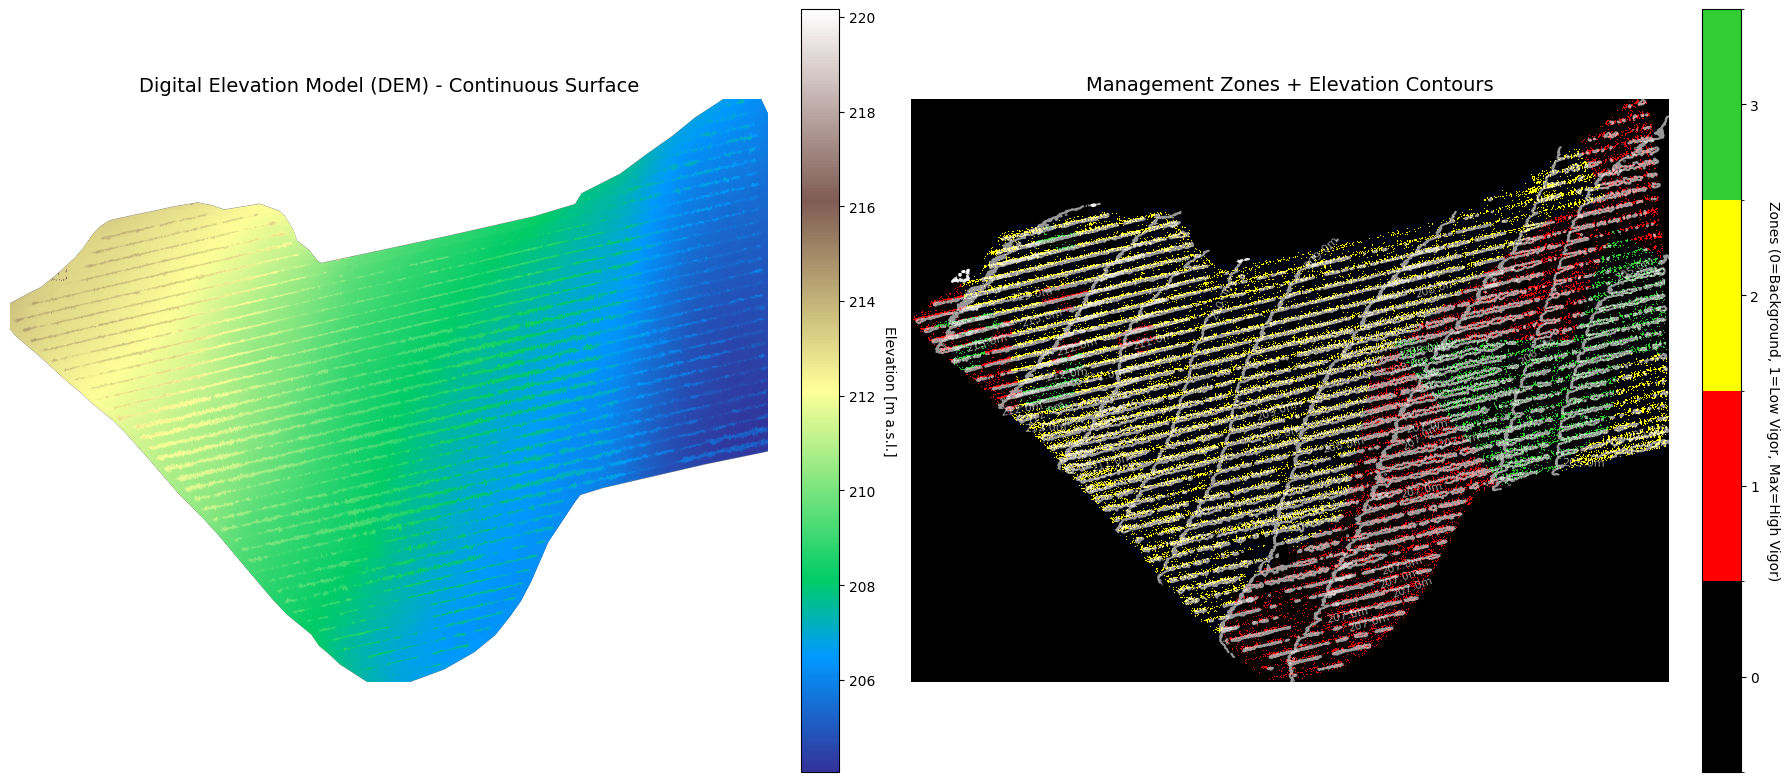

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# PLOT 1: Elevation Map (DEM) CONTINUOUS
im1 = axes[0].imshow(dem_masked_full, cmap='terrain')
axes[0].set_title('Digital Elevation Model (DEM) - Continuous Surface', fontsize=14)
axes[0].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('Elevation [m a.s.l.]', rotation=270, labelpad=15)

# PLOT 2: Management Zones with ELEVATION CONTOURS
step = 10 
preview_map = final_casp_clusters[::step, ::step].astype(np.uint8)

im2 = axes[1].imshow(preview_map, cmap=cmap_zones, norm=norm, interpolation='nearest')
axes[1].set_title('Management Zones + Elevation Contours', fontsize=14)
axes[1].axis('off')

dem_preview = dem[::step, ::step]
dem_preview_masked = np.ma.masked_where(dem_preview <= 0, dem_preview)
contours = axes[1].contour(dem_preview_masked, levels=15, colors='white', alpha=0.6, linewidths=1.5)
axes[1].clabel(contours, inline=True, fontsize=8, fmt='%.1fm')

cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, ticks=range(optimal_k + 1))
cbar2.set_label('Zones (0=Background, 1=Low Vigor, Max=High Vigor)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

We can observe correlation between the clusters and the elevation model. It may indicate that topography-driven water dynamics like rapid runoff on peaks and pooling in depressions can influence indexes.

## Milestone 29.04 - Comparison of Clustering Methods

Below we compare 4 additional clustering algorithms on the same scaled multispectral features (NIR, R, G, NDRE, NDVI).

| Method | Key idea |
|---|---|
| K-Means | Baseline — already computed above |
| Mini-Batch K-Means | Fast approximation of K-Means, fits large rasters |
| Agglomerative (Ward) | Hierarchical, merges similar pixels bottom-up |
| Spectral Clustering | Graph-based, captures non-convex zone shapes |
| Fuzzy C-Means | Soft: each pixel gets partial membership to all zones |

All methods use the same `optimal_k` and the same random subsamples for a fair comparison.

In [18]:
from sklearn.cluster import AgglomerativeClustering, MiniBatchKMeans, SpectralClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import pairwise_distances_argmin_min
import time
import pandas as pd

comparison_results = []

np.random.seed(42)
SAMPLE_LARGE = min(30000, scaled_data.shape[0])
SAMPLE_SMALL = min(5000,  scaled_data.shape[0])

idx_large = np.random.choice(scaled_data.shape[0], size=SAMPLE_LARGE, replace=False)
idx_small = np.random.choice(scaled_data.shape[0], size=SAMPLE_SMALL, replace=False)

X_large = scaled_data[idx_large]
X_small = scaled_data[idx_small]

print(f'Large sample: {X_large.shape} | Small sample: {X_small.shape}')

Large sample: (30000, 5) | Small sample: (5000, 5)


In [ ]:
def sort_labels_by_ndre(labels, features_unscaled):
    """Re-label clusters 1..K sorted by mean NDRE ascending (most stressed → healthiest)."""
    uniq = np.unique(labels)
    means = [(c, np.mean(features_unscaled[labels == c, 0])) for c in uniq]
    means.sort(key=lambda x: x[1])
    mapping = {old: new + 1 for new, (old, _) in enumerate(means)}
    return np.array([mapping[l] for l in labels])


def record_metrics(name, labels, X, fit_time_s):
    """Compute standard cluster quality metrics and append to comparison_results."""
    sil = silhouette_score(X, labels, sample_size=min(5000, len(labels)), random_state=42)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    sizes   = {c: int(np.sum(labels == c)) for c in np.unique(labels)}
    balance = min(sizes.values()) / max(sizes.values())
    comparison_results.append({
        'Method':                  name,
        'Silhouette ↑':            round(sil, 4),
        'Davies-Bouldin ↓':        round(db, 4),
        'Calinski-Harabasz ↑':     round(ch, 1),
        'Zone Balance ↑':          round(balance, 3),
        'Fit Time (s)':            round(fit_time_s, 2),
    })
    print(f"[{name:30s}] Sil={sil:.4f} | DB={db:.4f} | CH={ch:.0f} | Balance={balance:.3f} | Time={fit_time_s:.2f}s")

Helpers defined.


### 1. K-Means (baseline)

Adds the baseline K-Means to the comparison table.

In [ ]:
t0 = time.time()
km = KMeans(n_clusters=optimal_k, random_state=123, n_init=10)
km_labels = km.fit_predict(X_large)
km_time = time.time() - t0

km_labels_sorted = sort_labels_by_ndre(km_labels, unscaled_data[idx_large])
record_metrics('K-Means', km_labels_sorted, X_large, km_time)

# Full 2-D map
full_km_labels  = km.predict(scaled_data)
full_km_sorted  = sort_labels_by_ndre(full_km_labels, unscaled_data)
km_map = np.zeros_like(ndre, dtype=int)
km_map[valid_mask_2d] = full_km_sorted
print('K-Means map reconstructed.')

[K-Means                       ] Sil=0.3049 | DB=1.4785 | CH=21715 | Balance=0.743 | Time=0.10s
K-Means map reconstructed.


### 2. Mini-Batch K-Means

Uses random mini-batches instead of the full dataset each iteration — 10–20× faster while giving nearly identical zone boundaries.

In [21]:
t0 = time.time()
mbkm = MiniBatchKMeans(n_clusters=optimal_k, random_state=123, n_init=10, batch_size=4096)
mbkm.fit(scaled_data)           # trains on ALL valid pixels
mbkm_labels_full = mbkm.predict(scaled_data)
mbkm_time = time.time() - t0

mbkm_sorted_full = sort_labels_by_ndre(mbkm_labels_full, unscaled_data)
record_metrics('Mini-Batch K-Means', mbkm_sorted_full[idx_large], X_large, mbkm_time)

mbkm_map = np.zeros_like(ndre, dtype=int)
mbkm_map[valid_mask_2d] = mbkm_sorted_full
print('Mini-Batch K-Means map reconstructed.')

[Mini-Batch K-Means            ] Sil=0.3054 | DB=1.4785 | CH=21714 | Balance=0.739 | Time=9.18s
Mini-Batch K-Means map reconstructed.


### 3. Agglomerative Clustering — Ward linkage

Builds a dendrogram by repeatedly merging the two most similar groups.
Ward linkage minimises within-cluster variance (similar goal to K-Means but hierarchically).

Running on small sample 5 000 pixels; centroids are then used to predict the full map.

In [22]:
t0 = time.time()
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg.fit_predict(X_small)
agg_time = time.time() - t0

agg_labels_sorted = sort_labels_by_ndre(agg_labels, unscaled_data[idx_small])
record_metrics('Agglomerative (Ward)', agg_labels_sorted, X_small, agg_time)

# Derive centroids and assign full dataset via nearest-centroid
agg_centroids = np.array([
    X_small[agg_labels_sorted == c].mean(axis=0) for c in range(1, optimal_k + 1)
])
agg_full_0idx, _ = pairwise_distances_argmin_min(scaled_data, agg_centroids)
agg_full_labels   = agg_full_0idx + 1

agg_map = np.zeros_like(ndre, dtype=int)
agg_map[valid_mask_2d] = agg_full_labels
print('Agglomerative map reconstructed.')

[Agglomerative (Ward)          ] Sil=0.2832 | DB=1.4873 | CH=3384 | Balance=0.396 | Time=0.80s
Agglomerative map reconstructed.


### 4. Spectral Clustering

Constructs a similarity graph (k-NN, affinity) and clusters pixels in the Laplacian eigenspace.
Can discover non-convex, elongated zone shapes that K-Means misses.
Limited to samll sample due to computational cost

In [23]:
t0 = time.time()
spec = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors',
                          n_neighbors=15, random_state=123, n_jobs=-1)
spec_labels = spec.fit_predict(X_small)
spec_time = time.time() - t0

spec_labels_sorted = sort_labels_by_ndre(spec_labels, unscaled_data[idx_small])
record_metrics('Spectral Clustering', spec_labels_sorted, X_small, spec_time)

spec_centroids = np.array([
    X_small[spec_labels_sorted == c].mean(axis=0) for c in range(1, optimal_k + 1)
])
spec_full_0idx, _ = pairwise_distances_argmin_min(scaled_data, spec_centroids)
spec_full_labels   = spec_full_0idx + 1

spec_map = np.zeros_like(ndre, dtype=int)
spec_map[valid_mask_2d] = spec_full_labels
print('Spectral map reconstructed.')

[Spectral Clustering           ] Sil=0.2748 | DB=1.2589 | CH=3332 | Balance=0.185 | Time=1.75s
Spectral map reconstructed.


### 5. Fuzzy C-Means Soft Clustering

Unlike hard clustering, FCM assigns a membership degree (0–1) per zone per pixel.

Important because of transition pixels with low maximum membership are the most uncertain — prime candidates for targeted soil sampling or ground-truth verification.

In [24]:
try:
    import skfuzzy as fuzz
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'scikit-fuzzy', '-q'], check=True)
    import skfuzzy as fuzz

# FCM expects (n_features, n_samples)
X_fcm = X_large.T

t0 = time.time()
cntr, u_membership, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_fcm, c=optimal_k, m=2.0, error=0.005, maxiter=150, init=None, seed=42
)
fcm_time = time.time() - t0

fcm_labels_raw    = np.argmax(u_membership, axis=0)
fcm_labels_sorted = sort_labels_by_ndre(fcm_labels_raw, unscaled_data[idx_large])
record_metrics('Fuzzy C-Means', fcm_labels_sorted, X_large, fcm_time)

# Predict full dataset
u_full, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
    scaled_data.T, cntr, m=2.0, error=0.005, maxiter=150
)
fcm_full_raw    = np.argmax(u_full, axis=0)
fcm_full_sorted = sort_labels_by_ndre(fcm_full_raw, unscaled_data)

# Uncertainty = 1 - max membership (0=certain, 1=totally ambiguous)
fcm_uncertainty = 1.0 - np.max(u_full, axis=0)
fcm_uncertainty_2d = np.full(ndre.shape, np.nan)
fcm_uncertainty_2d[valid_mask_2d] = fcm_uncertainty

fcm_map = np.zeros_like(ndre, dtype=int)
fcm_map[valid_mask_2d] = fcm_full_sorted
print('Fuzzy C-Means map reconstructed.')

[Fuzzy C-Means                 ] Sil=0.2908 | DB=1.5998 | CH=21128 | Balance=0.850 | Time=0.85s
Fuzzy C-Means map reconstructed.


## Spatial Coverage Metrics

I use and create some metrics

| Metric | Definition | Goal |
|--------|-----------|------|
| **Zone Balance** | min_size / max_size across zones | ≈ 1.0 = equal coverage |
| **Compactness** | mean circularity of connected components (4π·A / P²) | Higher = fewer tractor turns |
| **Fragmentation** | n_connected_components / n_pixels | Lower = fewer isolated patches |
| **Coverage Smoothness** | 1 − (boundary_pixels / valid_pixels) | Higher = cleaner zone edges |
| **Entropy** | Shannon entropy of zone area proportions | Low = one dominant zone|

In [ ]:
from skimage.measure import label as sk_label, regionprops
from scipy.ndimage import binary_erosion

def spatial_coverage_metrics(cluster_map_2d, valid_mask, n_clusters, method_name):
    """Field-operability metrics for a 2-D cluster map."""
    metrics = {'Method': method_name}
    sizes, compactnesses = [], []
    total_frag    = 0
    boundary_pix  = 0

    for z in range(1, n_clusters + 1):
        bin_mask = (cluster_map_2d == z)
        n_pix    = int(np.sum(bin_mask))
        sizes.append(n_pix)

        # Fragmentation: connected component count normalised by pixels
        labeled, n_comp = sk_label(bin_mask, return_num=True, connectivity=2)
        total_frag += n_comp / max(n_pix, 1)

        # Compactness: mean circularity across components
        props = regionprops(labeled)
        comp_vals = [
            4 * np.pi * p.area / (p.perimeter ** 2)
            for p in props if p.perimeter > 0
        ]
        compactnesses.append(np.mean(comp_vals) if comp_vals else 0.0)

        # Boundary pixels (erode and subtract)
        eroded = binary_erosion(bin_mask, structure=np.ones((3, 3)))
        boundary_pix += int(np.sum(bin_mask) - np.sum(eroded))

    total_valid = int(np.sum(valid_mask))

    metrics['Zone Balance ↑']   = round(min(sizes) / max(sizes), 3)
    metrics['Compactness ↑']    = round(float(np.mean(compactnesses)), 4)
    metrics['Fragmentation ↓']  = round(total_frag / n_clusters, 6)
    metrics['Smoothness ↑']     = round(1 - boundary_pix / total_valid, 4)
    props_arr = np.array(sizes) / total_valid
    metrics['Zone Entropy']     = round(-float(np.sum(props_arr * np.log2(props_arr + 1e-12))), 4)

    print(f"[{method_name:30s}] "
          f"Balance={metrics['Zone Balance ↑']:.3f} | "
          f"Compact={metrics['Compactness ↑']:.4f} | "
          f"Frag={metrics['Fragmentation ↓']:.6f} | "
          f"Smooth={metrics['Smoothness ↑']:.4f} | "
          f"Entropy={metrics['Zone Entropy']:.4f}")
    return metrics

spatial_coverage_metrics defined.


In [ ]:
# Apply CaSP smoothing to all raw maps
def apply_casp(raw_map, valid_mask, n_clusters, min_island_size=5000):
    smoothed    = np.zeros_like(raw_map)
    valid_large = np.zeros_like(raw_map, dtype=bool)
    for c in range(1, n_clusters + 1):
        bm = (raw_map == c)
        cm = remove_small_objects(bm, min_size=min_island_size)
        smoothed[cm] = c
        valid_large |= cm
    _, idx = distance_transform_edt(~valid_large, return_indices=True)
    out = smoothed[idx[0], idx[1]]
    out[~valid_mask] = 0
    return out

print('Applying CaSP to all maps...')
km_casp    = apply_casp(km_map,   valid_mask_2d, optimal_k)
mbkm_casp  = apply_casp(mbkm_map, valid_mask_2d, optimal_k)
agg_casp   = apply_casp(agg_map,  valid_mask_2d, optimal_k)
spec_casp  = apply_casp(spec_map, valid_mask_2d, optimal_k)
fcm_casp   = apply_casp(fcm_map,  valid_mask_2d, optimal_k)
gmm_casp   = final_casp_clusters   # already computed above
print('Done.')

spatial_results = []
for name, cmap in [
    ('GMM + CaSP (paper)',        gmm_casp),
    ('K-Means + CaSP',            km_casp),
    ('Mini-Batch KMeans + CaSP',  mbkm_casp),
    ('Agglomerative + CaSP',      agg_casp),
    ('Spectral + CaSP',           spec_casp),
    ('Fuzzy C-Means + CaSP',      fcm_casp),
]:
    spatial_results.append(spatial_coverage_metrics(cmap, valid_mask_2d, optimal_k, name))

Applying CaSP to all maps...
Done.
[GMM + CaSP (paper)            ] Balance=0.291 | Compact=2.8008 | Frag=0.013719 | Smooth=0.5762 | Entropy=1.4194
[K-Means + CaSP                ] Balance=0.028 | Compact=2.8252 | Frag=0.014900 | Smooth=0.5753 | Entropy=0.9677
[Mini-Batch KMeans + CaSP      ] Balance=0.028 | Compact=2.8252 | Frag=0.014900 | Smooth=0.5753 | Entropy=0.9677
[Agglomerative + CaSP          ] Balance=0.020 | Compact=2.8255 | Frag=0.013887 | Smooth=0.5766 | Entropy=1.0590
[Spectral + CaSP               ] Balance=0.132 | Compact=2.7980 | Frag=0.015617 | Smooth=0.5762 | Entropy=0.9676
[Fuzzy C-Means + CaSP          ] Balance=0.026 | Compact=2.8327 | Frag=0.015195 | Smooth=0.5755 | Entropy=0.8740


## Comparison Tables

In [27]:
print('\n=== CLUSTERING QUALITY METRICS (sample-based) ===')
df_quality = pd.DataFrame(comparison_results).set_index('Method')
print(df_quality.to_string())

print('\n=== SPATIAL COVERAGE METRICS (full map, after CaSP) ===')
df_spatial = pd.DataFrame(spatial_results).set_index('Method')
print(df_spatial.to_string())


=== CLUSTERING QUALITY METRICS (sample-based) ===
                      Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  Zone Balance ↑  Fit Time (s)
Method                                                                                                 
K-Means                     0.3049            1.4785              21714.6           0.743          0.10
Mini-Batch K-Means          0.3054            1.4785              21713.8           0.739          9.18
Agglomerative (Ward)        0.2832            1.4873               3384.4           0.396          0.80
Spectral Clustering         0.2748            1.2589               3332.4           0.185          1.75
Fuzzy C-Means               0.2908            1.5998              21128.5           0.850          0.85

=== SPATIAL COVERAGE METRICS (full map, after CaSP) ===
                          Zone Balance ↑  Compactness ↑  Fragmentation ↓  Smoothness ↑  Zone Entropy
Method                                                         

We can observe that clustering quality and coverage metrics are sometimes different. First is focused on clusters features similarity and second more about mechanistic route of robot. 

Clustering Quality Metrics:
- Silhouette Score & Davies-Bouldin Index (DBI): These measure the internal cohesion of a cluster and its distance to neighboring clusters. A high Silhouette and low DBI indicate that the zones are mathematically distinct and well-separated in the feature space.

- Calinski-Harabasz Index (CH): Computes the ratio of between-cluster variance to within-cluster variance. High values indicate highly dense and strictly separated data points.

Spatial Coverage Metrics - robot navigation:

- Zone Balance: Measures the size ratio between the smallest and largest zones. A balanced map ensures that localized stress areas are not swallowed by a single, massive dominant zone.

- Compactness: Calculates how closely a zone's shape resembles a perfect circle. High compactness ensures large, rounded patches that allow for smooth driving and minimal actuator switching.

- Fragmentation and smoothness: Fragmentation counts the number of isolated "islands," while smoothness evaluates the curves of the zone borders.

- Zone Entropy: Measures the informational diversity of the map. Higher entropy means the algorithm successfully preserved and mapped the natural variability of the field rather than averaging it out into a one block.

Looking at the mathematical dimension , K-Means and its Mini-Batch variant dominate the competition. They achieve the highest Calinski-Harabasz scores ($\sim$21,714) and strong Silhouette scores ($\sim$0.305), indicating highly cohesive and well-separated clusters in the feature space. This purely numerical efficiency explains why basic K-Means is often recommended as a baseline in remote sensing literature like in our paper. 

The spatial coverage metrics reveal a critical practical flaw. Once the CaSP is applied to make the maps, hard clustering algorithms like K-Means suffer a severe drop in Zone Balance (from 0.743 to 0.028). This means a single zone disproportionately swallows almost the entire field, effectively erasing the localized stress detection.In contrast, the GMM + CaSP method successfully bridges this gap. It maintains a healthy Zone Balance (0.291) and achieves the highest Zone Entropy (1.419), preserving meaningful spatial diversity and correctly identifying field anomalies. 

## Visual Comparison of All Methods (after CaSP smoothing)

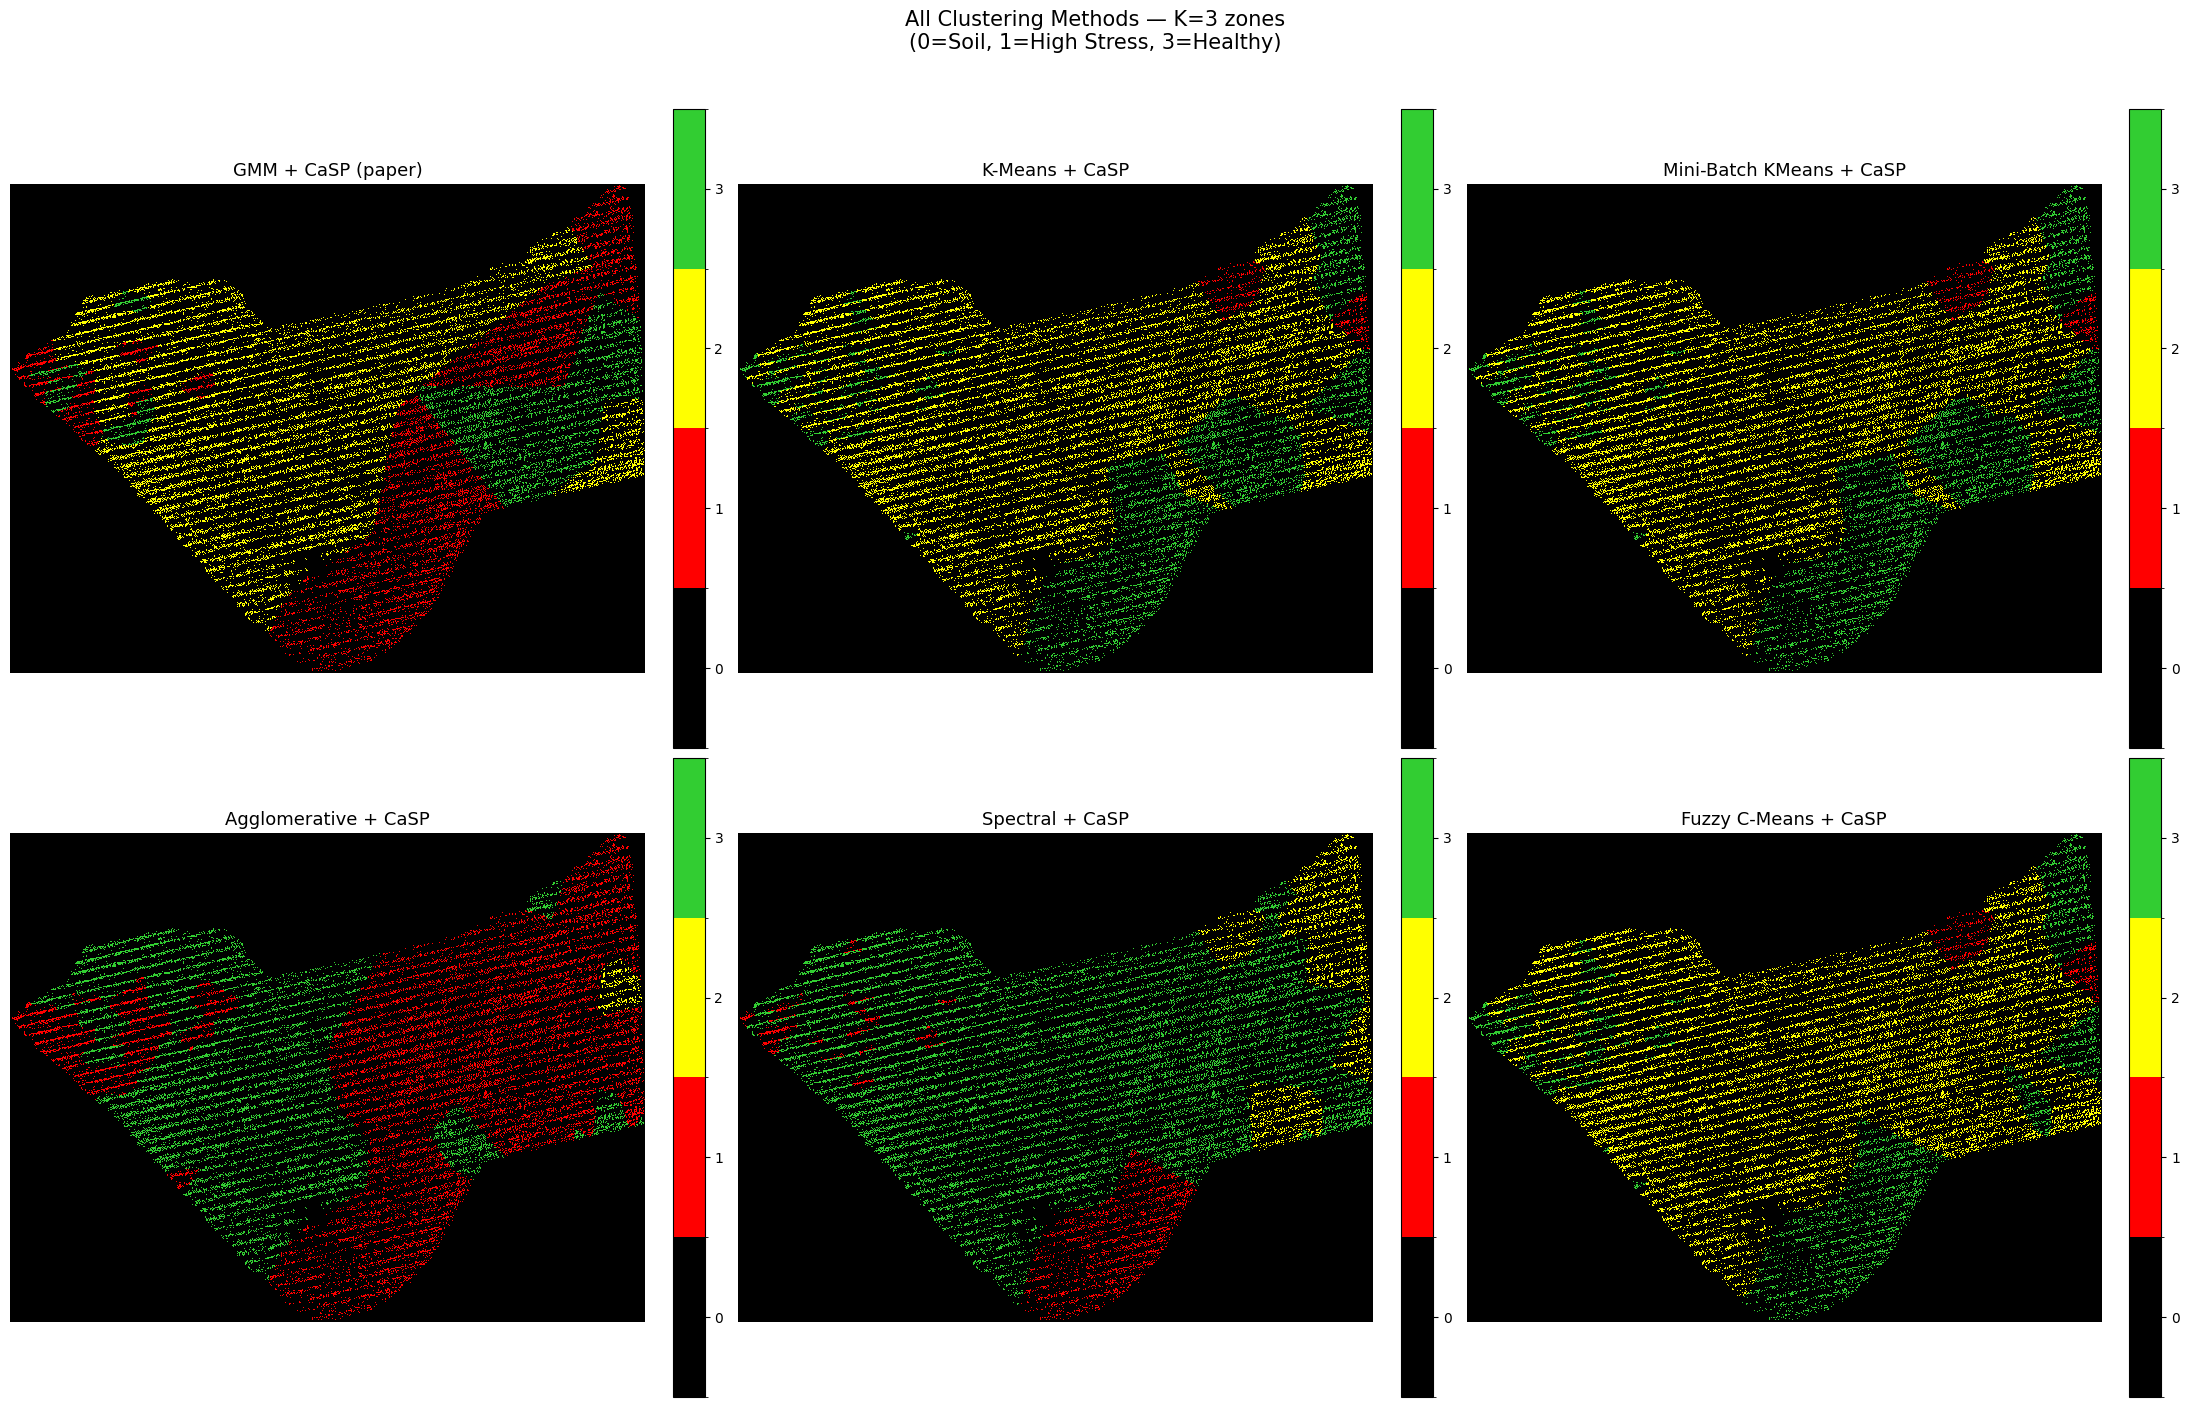

In [28]:
step = 10
maps_to_show = [
    ('GMM + CaSP (paper)',        gmm_casp),
    ('K-Means + CaSP',            km_casp),
    ('Mini-Batch KMeans + CaSP',  mbkm_casp),
    ('Agglomerative + CaSP',      agg_casp),
    ('Spectral + CaSP',           spec_casp),
    ('Fuzzy C-Means + CaSP',      fcm_casp),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

color_list = ['black', 'red', 'yellow', 'limegreen', 'dodgerblue', 'darkviolet']
cmap_zones = ListedColormap(color_list[:optimal_k + 1])
bounds = np.arange(optimal_k + 2) - 0.5
norm   = BoundaryNorm(bounds, cmap_zones.N)

for ax, (title, cmap) in zip(axes, maps_to_show):
    preview = cmap[::step, ::step].astype(np.uint8)
    im = ax.imshow(preview, cmap=cmap_zones, norm=norm, interpolation='nearest')
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    plt.colorbar(im, ax=ax, ticks=range(optimal_k + 1), fraction=0.046, pad=0.04)

plt.suptitle(
    f'All Clustering Methods — K={optimal_k} zones\n(0=Soil, 1=High Stress, {optimal_k}=Healthy)',
    fontsize=15, y=1.01
)
plt.tight_layout()
plt.show()

## Fuzzy C-Means: Uncertainty Map

Pixels with high uncertainty (close to 0.5 membership in two zones) are agronomically similar

Pixels with uncertainty > 0.35 (ambiguous zone): 63.1% of canopy


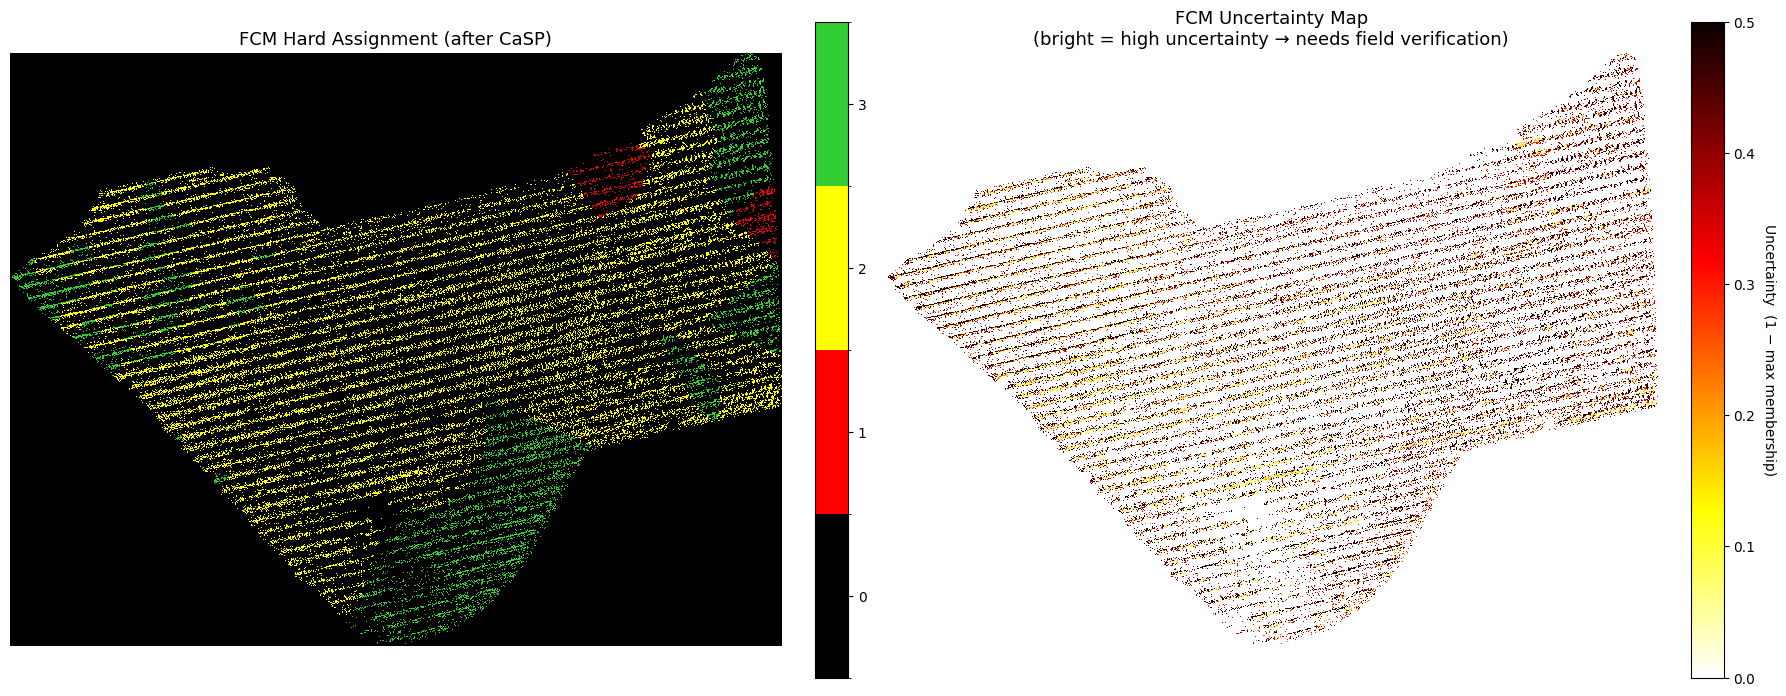

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
step = 10

im1 = axes[0].imshow(fcm_casp[::step, ::step].astype(np.uint8),
                     cmap=cmap_zones, norm=norm, interpolation='nearest')
axes[0].set_title('FCM Hard Assignment (after CaSP)', fontsize=13)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], ticks=range(optimal_k + 1), fraction=0.046, pad=0.04)

im2 = axes[1].imshow(fcm_uncertainty_2d[::step, ::step],
                     cmap='hot_r', vmin=0, vmax=0.5, interpolation='nearest')
axes[1].set_title('FCM Uncertainty Map\n(bright = high uncertainty → needs field verification)', fontsize=13)
axes[1].axis('off')
cbar = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Uncertainty  (1 − max membership)', rotation=270, labelpad=15)

pct = np.sum((~np.isnan(fcm_uncertainty_2d)) & (fcm_uncertainty_2d > 0.35)) / np.sum(valid_mask_2d) * 100
print(f'Pixels with uncertainty > 0.35 (ambiguous zone): {pct:.1f}% of canopy')

plt.tight_layout()
plt.show()